In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import rioxarray
import numpy as np
from rasterio.enums import Resampling

In [2]:
current_dir = Path.cwd()
data_dir = current_dir.parent / "data"

copernicus_data = []
for file in (data_dir / "copernicus").glob("*_meter.tif"):
    with rioxarray.open_rasterio(file) as data:
        copernicus_data.append(data.squeeze().drop_vars("band").load())

dataforsyningen_data = []
for file in (data_dir / "dataforsyningen").glob("*_meter.tif"):
    with rioxarray.open_rasterio(file) as data:
        dataforsyningen_data.append(data.squeeze().drop_vars("band").load())

In [3]:
copernicus_first = copernicus_data[0]
dataforsyningen_first = dataforsyningen_data[0]

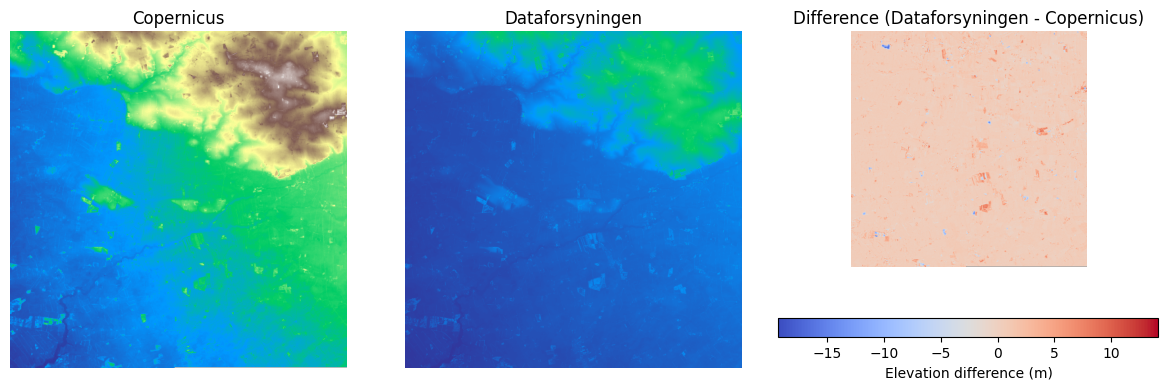

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Match Dataforsyningen to the exact Copernicus grid to get difference
dataforsyningen_on_copernicus = dataforsyningen_first.rio.reproject_match(
    copernicus_first,
    resampling=Resampling.bilinear,
    nodata=np.nan,
    dtype="float32",
)
difference = dataforsyningen_on_copernicus - copernicus_first

axes[0].imshow(copernicus_first, cmap="terrain")
axes[0].set_title("Copernicus")

axes[1].imshow(dataforsyningen_first, cmap="terrain")
axes[1].set_title("Dataforsyningen")

difference_image = axes[2].imshow(
    difference,
    cmap="coolwarm"
)

axes[2].set_title("Difference (Dataforsyningen - Copernicus)")
fig.colorbar(
    difference_image,
    ax=axes[2],
    label="Elevation difference (m)",
    orientation="horizontal",
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

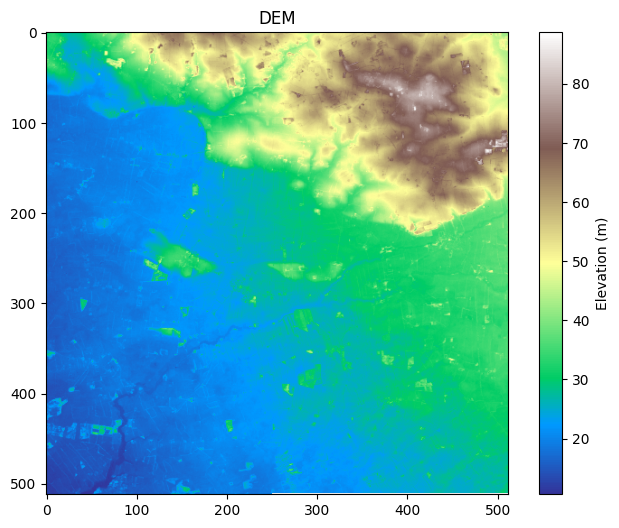

In [5]:
plt.figure(figsize=(8, 6))
plt.imshow(copernicus_first, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("DEM")
plt.show()

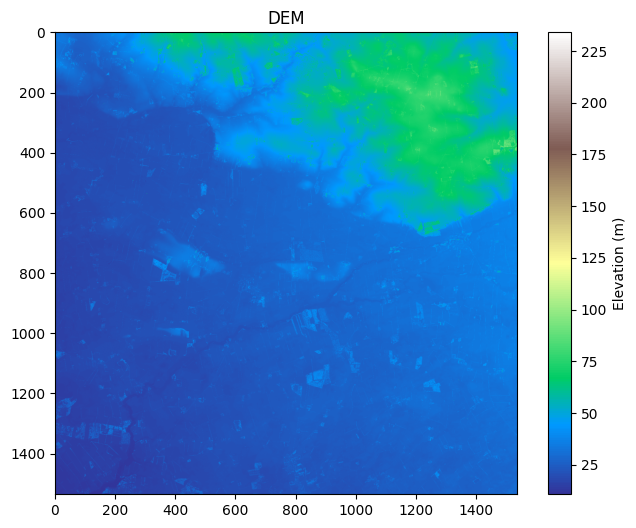

In [6]:
plt.figure(figsize=(8, 6))
plt.imshow(dataforsyningen_first, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("DEM")
plt.show()